# Task 5.2: 逻辑回归 & 随机森林 —— 模型训练与分析

本 notebook 对两个模型在北美年龄分级预测任务上的训练结果进行深度分析。

**训练由 `train_models.py` 完成，模型和指标已保存到 `output/`，notebook 只读不写。**

- 数据：Task 4 TF-IDF 特征（758 维，5 分类，训练/验证/测试 = 810/202/253）
- 逻辑回归：`l1_ratio=1.0` (L1), `C=10.0`, `solver=saga`
- 随机森林：`n_estimators=500`, `max_depth=None`, `min_samples_leaf=1`, `max_features=0.3`

## 1. 环境与数据加载

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

TASK_DIR = Path.cwd()
OUTPUT_DIR = TASK_DIR / "output"
TASK4_DIR = Path("../task4_feature_engineering/output")
MPL_DIR = TASK_DIR / ".matplotlib"

import os
os.environ.setdefault("MPLCONFIGDIR", str(MPL_DIR))
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})
sns.set_style("whitegrid")

CLASS_NAMES = ["Everyone", "Everyone 10+", "Teen", "Mature 17+", "Adults only 18+"]

In [2]:
# ── 加载 output/ 中的训练结果 ──
with open(OUTPUT_DIR / "metrics.json", encoding="utf-8") as f:
    metrics = json.load(f)
comparison_df = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")

# 加载训练好的模型
lr_model = joblib.load(OUTPUT_DIR / "logistic_regression_model.joblib")
rf_model = joblib.load(OUTPUT_DIR / "random_forest_model.joblib")

# 加载分类报告
def load_cr(model_name, split):
    return pd.read_csv(OUTPUT_DIR / f"classification_report_{model_name}_{split}.csv")

lr_cr_test = load_cr("logistic_regression", "test")
rf_cr_test = load_cr("random_forest", "test")

# ── 加载特征数据与词典 ──
from scipy import sparse
X_train = sparse.load_npz(TASK4_DIR / "X_train.npz").toarray()
X_test = sparse.load_npz(TASK4_DIR / "X_test.npz").toarray()
y_test = pd.read_csv(TASK4_DIR / "y_test.csv")["label_id"].values

feature_dict = pd.read_csv(TASK4_DIR / "feature_dictionary.csv")
id_to_text = dict(zip(feature_dict["feature_index"].astype(int),
                       feature_dict["question_text"].fillna("") + " [" +
                       feature_dict["option_label"].fillna("") + "]"))

feature_names_raw = pd.read_csv(TASK4_DIR / "feature_names.csv")["feature_name"].tolist()

print("All data loaded.")
print(f"  LR test macro F1: {metrics['logistic_regression']['splits']['test']['macro_f1']:.4f}")
print(f"  RF test macro F1: {metrics['random_forest']['splits']['test']['macro_f1']:.4f}")

All data loaded.
  LR test macro F1: 0.9184
  RF test macro F1: 0.7971


## 2. 模型超参数

In [3]:
for model_key, label in [("logistic_regression", "Logistic Regression"),
                           ("random_forest", "Random Forest")]:
    params = metrics[model_key]["params"]
    display_params = {k: v for k, v in params.items()
                      if v is not None and k not in ("random_state", "n_jobs", "verbose", "warm_start")}
    print(f"{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    for k, v in display_params.items():
        print(f"  {k}: {v}")
    print()

Logistic Regression
  C: 10.0
  class_weight: {'0': 1.3846153846153846, '1': 1.8409090909090908, '2': 0.7465437788018433, '3': 0.6952789699570815, '4': 1.0451612903225806}
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: 1.0
  max_iter: 5000
  penalty: deprecated
  solver: saga
  tol: 0.0001

Random Forest
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: {'0': 1.3846153846153846, '1': 1.8409090909090908, '2': 0.7465437788018433, '3': 0.6952789699570815, '4': 1.0451612903225806}
  criterion: gini
  max_features: 0.3
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  n_estimators: 500
  oob_score: False



## 3. 模型性能

In [4]:
# Pivot table
pivot = comparison_df.pivot(index="model", columns="split",
                            values=["accuracy", "macro_f1", "weighted_f1", "macro_ovr_auc"])
pivot

accuracy            macro_f1           weighted_f1  \
split                    test       val      test       val        test   
model                                                                     
logistic_regression  0.920949  0.935644  0.918369  0.927815    0.921284   
random_forest        0.782609  0.811881  0.797081  0.811216    0.784504   

                              macro_ovr_auc            
split                     val          test       val  
model                                                  
logistic_regression  0.936552      0.976525  0.973021  
random_forest        0.810264      0.944748  0.955175

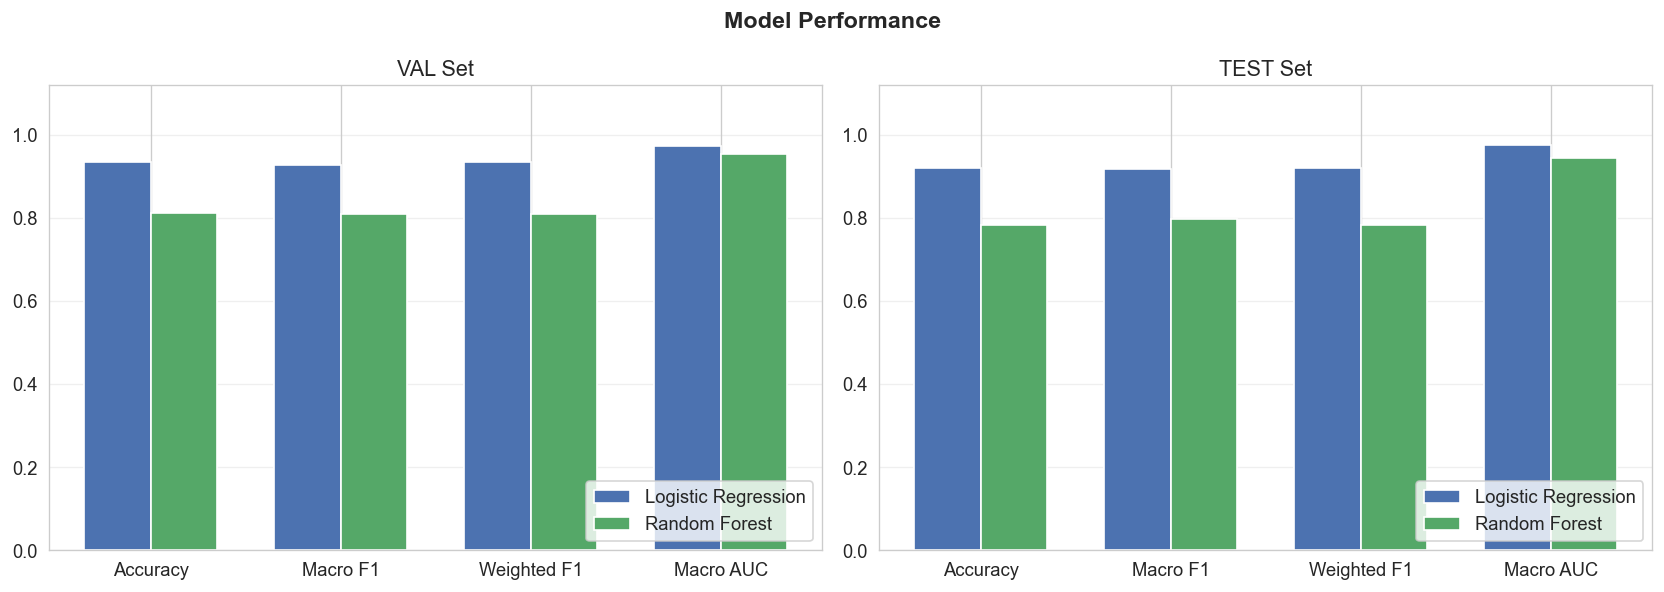

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, split in zip(axes, ["val", "test"]):
    subset = comparison_df[comparison_df["split"] == split]
    x = np.arange(4)
    width = 0.35
    mlist = ["accuracy", "macro_f1", "weighted_f1", "macro_ovr_auc"]
    labels = ["Accuracy", "Macro F1", "Weighted F1", "Macro AUC"]

    lr_vals = [subset[subset["model"] == "logistic_regression"][m].values[0] for m in mlist]
    rf_vals = [subset[subset["model"] == "random_forest"][m].values[0] for m in mlist]

    ax.bar(x - width/2, lr_vals, width, label="Logistic Regression", color="#4c72b0", edgecolor="white")
    ax.bar(x + width/2, rf_vals, width, label="Random Forest", color="#55a868", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.12)
    ax.set_title(f"{split.upper()} Set"); ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Model Performance", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In [6]:
# Classification reports
print("Logistic Regression — Test Set")
display(lr_cr_test.set_index("Unnamed: 0").style.format({
    "precision": "{:.4f}", "recall": "{:.4f}", "f1-score": "{:.4f}", "support": "{:.0f}"
}))

print("\nRandom Forest — Test Set")
display(rf_cr_test.set_index("Unnamed: 0").style.format({
    "precision": "{:.4f}", "recall": "{:.4f}", "f1-score": "{:.4f}", "support": "{:.0f}"
}))

Logistic Regression — Test Set


,precision,recall,f1-score,support
Unnamed: 0,,,,
Everyone,0.9211,0.9722,0.9459,36
Everyone 10+,0.8889,0.8571,0.8727,28
Teen,0.8553,0.9559,0.9028,68
Mature 17+,0.9571,0.9178,0.9371,73
Adults only 18+,1.0000,0.8750,0.9333,48
accuracy,0.9209,0.9209,0.9209,1
macro avg,0.9245,0.9156,0.9184,253
weighted avg,0.9252,0.9209,0.9213,253



Random Forest — Test Set


,precision,recall,f1-score,support
Unnamed: 0,,,,
Everyone,0.7895,0.8333,0.8108,36
Everyone 10+,0.7931,0.8214,0.8070,28
Teen,0.6706,0.8382,0.7451,68
Mature 17+,0.7903,0.6712,0.7259,73
Adults only 18+,1.0000,0.8125,0.8966,48
accuracy,0.7826,0.7826,0.7826,1
macro avg,0.8087,0.7953,0.7971,253
weighted avg,0.7981,0.7826,0.7845,253


Logistic Regression — Test Set


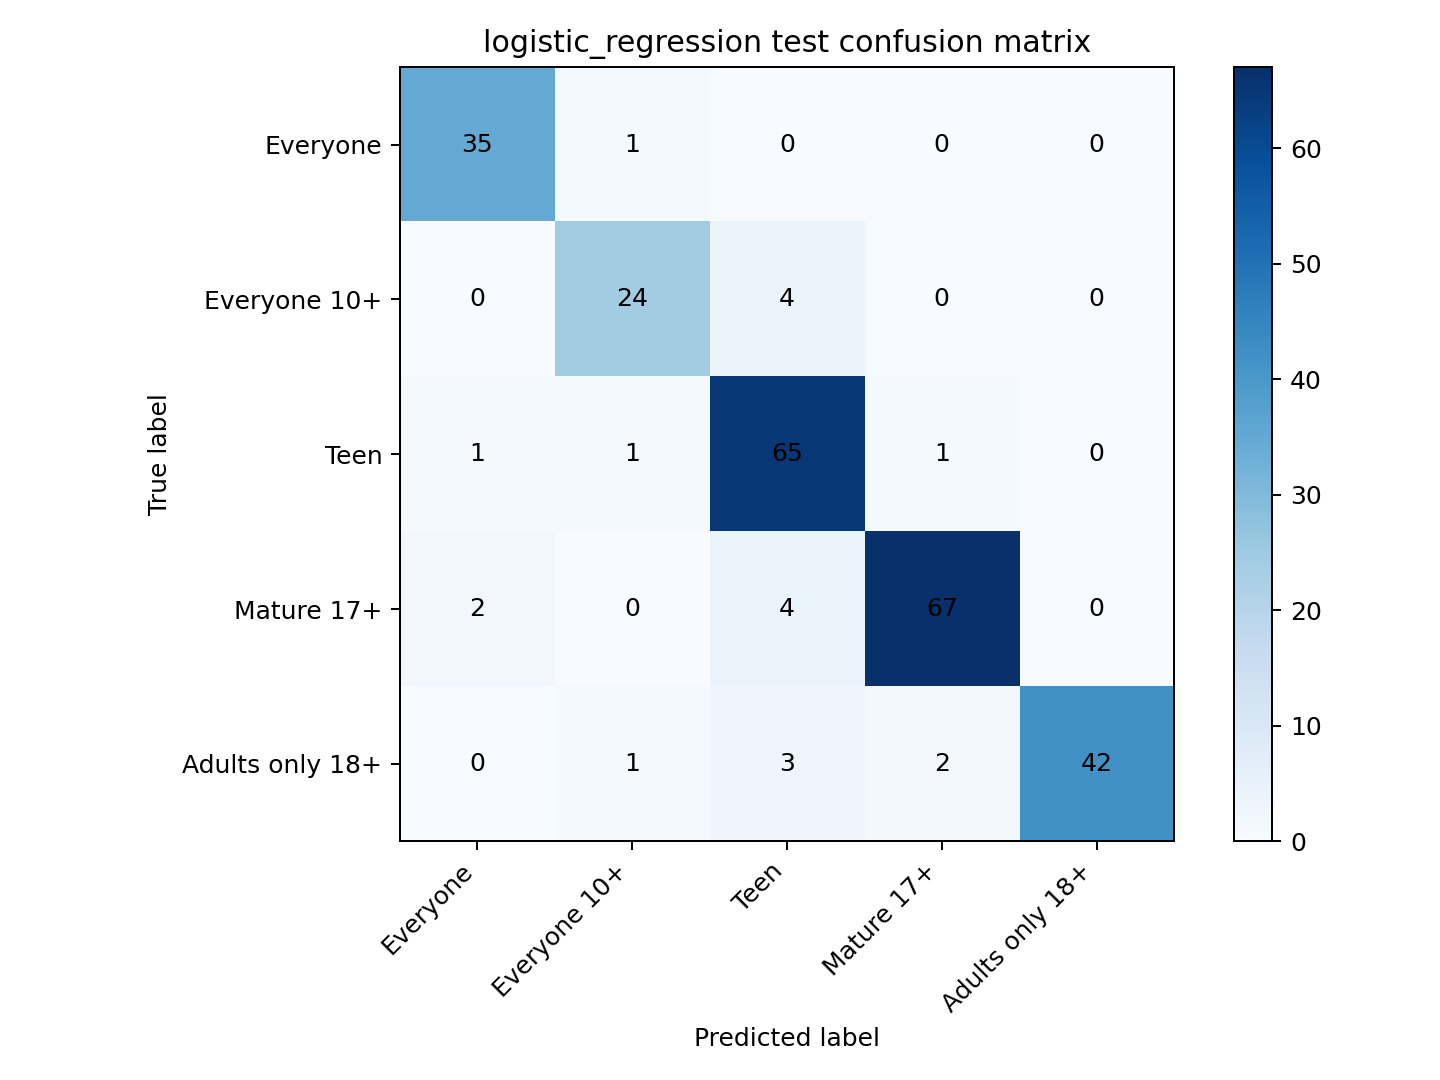


Random Forest — Test Set


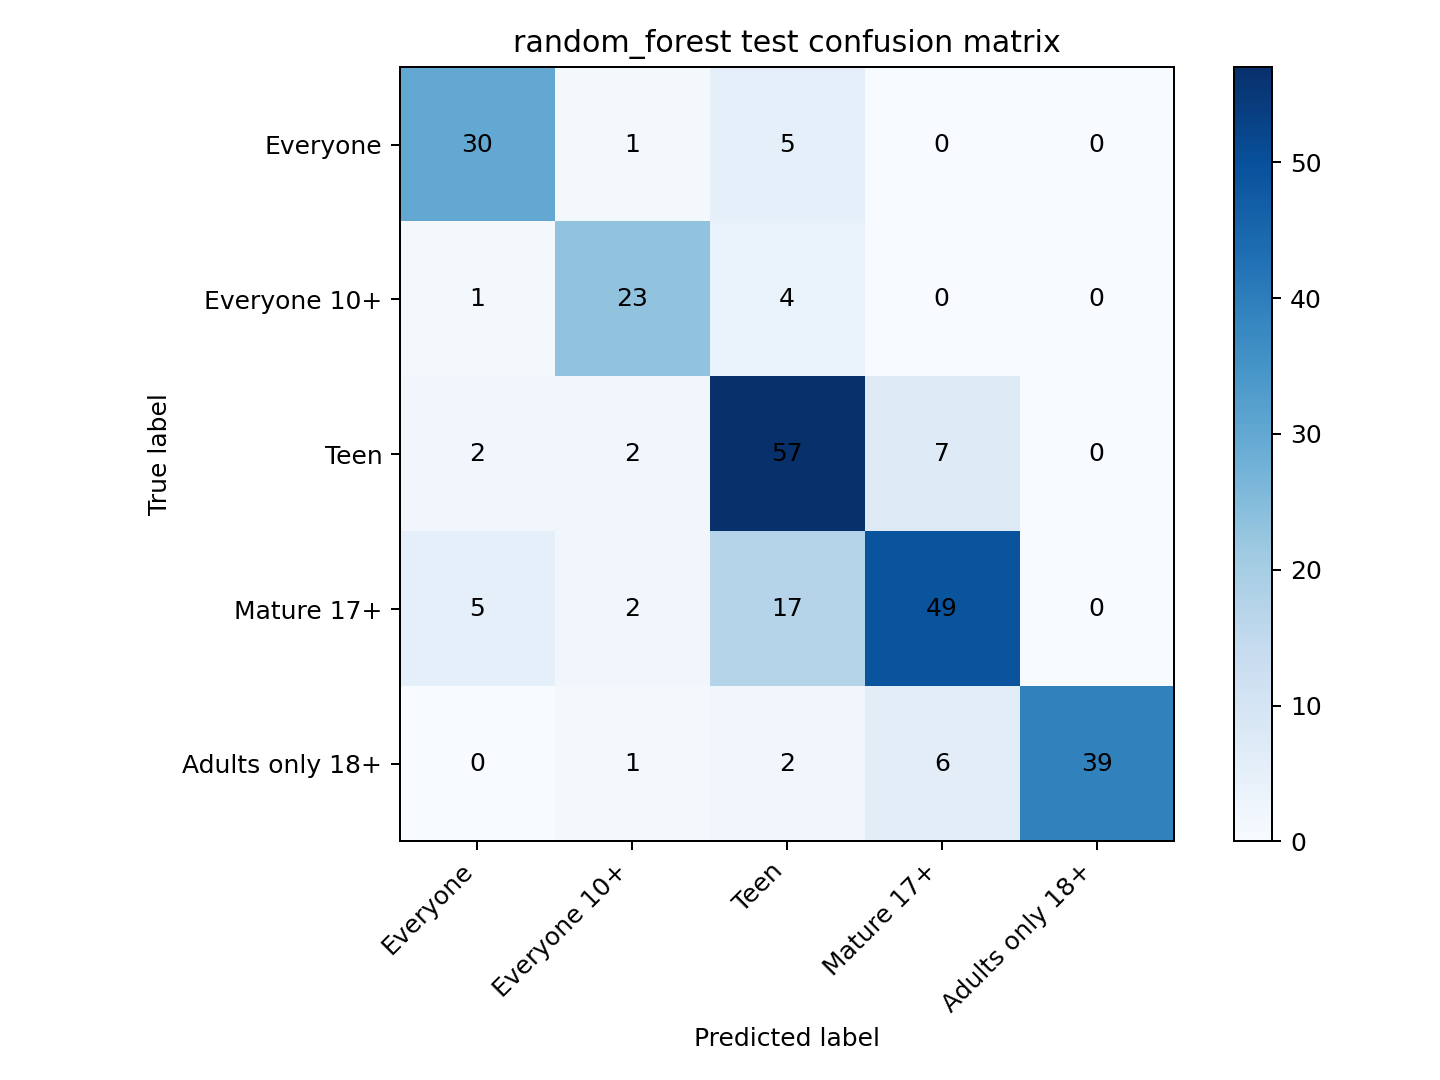

In [7]:
# Confusion matrices
from IPython.display import Image as IPImage, display as ip_display

print("Logistic Regression — Test Set")
ip_display(IPImage(filename=str(OUTPUT_DIR / "confusion_matrix_logistic_regression_test.png")))
print("\nRandom Forest — Test Set")
ip_display(IPImage(filename=str(OUTPUT_DIR / "confusion_matrix_random_forest_test.png")))

## 4. 逻辑回归 — L1 稀疏解与关键特征分析

L1 正则化的核心优势：自动将大量无关特征的系数压缩为 0，只保留真正有区分力的特征。
逻辑回归的 `coef_` 矩阵形状为 (5, 758)——每个类别一行，每列一个特征的权重。

总权重数: 3790 (5 classes x 758 features)
非零权重: 736
被 L1 压缩为 0 的权重: 3054 (80.6%)


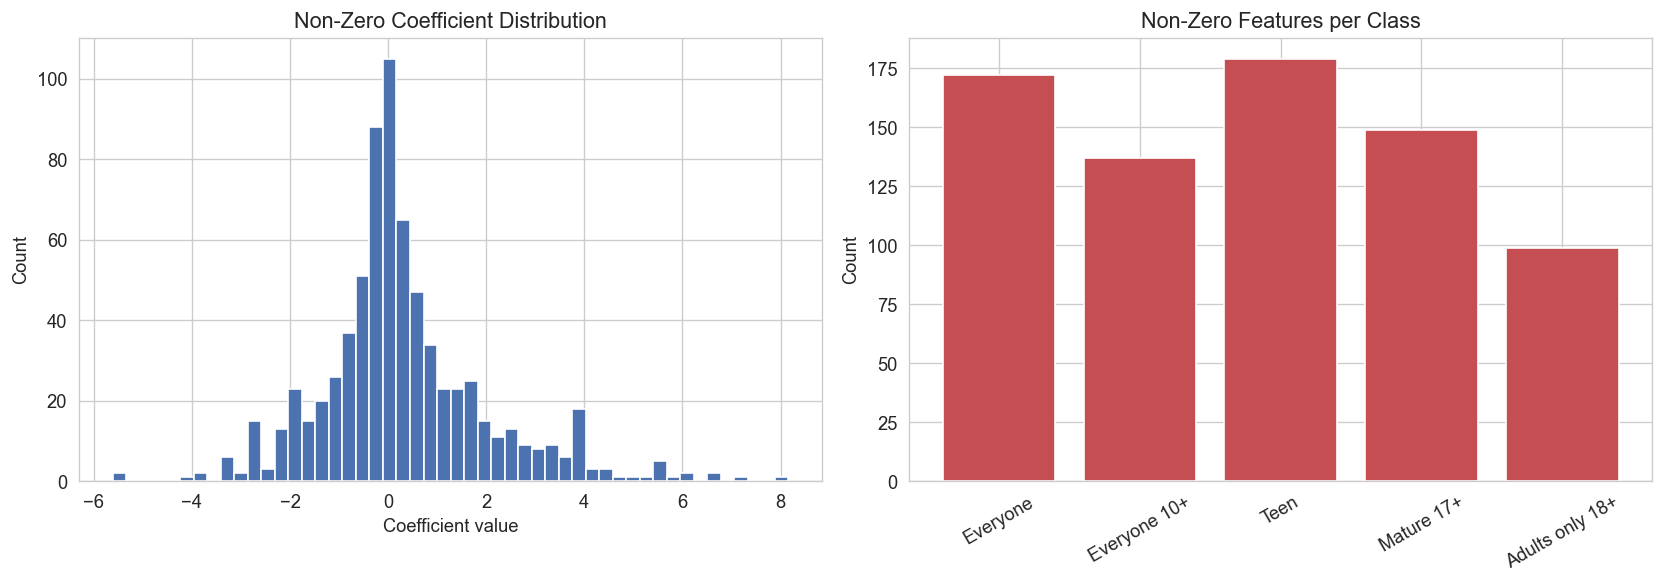

In [8]:
coef = lr_model.coef_  # shape (5, 758)

# ── L1 稀疏度 ──
total_weights = coef.size
nonzero_weights = int((coef != 0).sum())
zero_weights = total_weights - nonzero_weights
sparsity = zero_weights / total_weights * 100

print(f"总权重数: {total_weights} (5 classes x 758 features)")
print(f"非零权重: {nonzero_weights}")
print(f"被 L1 压缩为 0 的权重: {zero_weights} ({sparsity:.1f}%)")

# ── 系数分布 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_coef = coef.flatten()
axes[0].hist(all_coef[all_coef != 0], bins=50, color="#4c72b0", edgecolor="white")
axes[0].set_title("Non-Zero Coefficient Distribution")
axes[0].set_xlabel("Coefficient value"); axes[0].set_ylabel("Count")

nonzero_per_class = [(coef[i] != 0).sum() for i in range(5)]
axes[1].bar(CLASS_NAMES, nonzero_per_class, color="#c44e52", edgecolor="white")
axes[1].set_title("Non-Zero Features per Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [9]:
# ── 每类的 Top-10 关键特征 ──
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_coef = coef[class_idx]
    # 取绝对值最大的非零权重
    nonzero_idx = np.where(class_coef != 0)[0]
    top_k = nonzero_idx[np.argsort(np.abs(class_coef[nonzero_idx]))[::-1][:10]]

    print(f"\n{'='*70}")
    print(f"  {class_name} — Top-10 L1 特征 (正=推高概率, 负=压低概率)")
    print(f"{'='*70}")
    for rank, idx in enumerate(top_k, 1):
        text = id_to_text.get(idx, feature_names_raw[idx])
        # Truncate long text
        if len(text) > 85:
            text = text[:82] + "..."
        print(f"  {rank:2d}. [{class_coef[idx]:+.4f}] {text}")


  Everyone — Top-10 L1 特征 (正=推高概率, 负=压低概率)
   1. [-5.6167] Does the app have a pixelated or childlike style? [No]
   2. [-5.4526] Does the game have a pixelated or childlike style? [No]
   3. [+3.9900] Are these dating games prominently featured or a strong focus of the product? [No]
   4. [-3.2896] How is this violence presented in the game? [Rarely depicted from a close-up persp...
   5. [+3.2000] Tobacco [Reference]
   6. [-3.1374] Is the issuance of these digital assets a significant or promoted aspect of the pr...
   7. [-2.9774] What bodily functions are used for humorous purposes in the game? Please check all...
   8. [-2.8455] Is accessing this material the primary purpose of the app? [No]
   9. [-2.8423] Is this content the focus of the app? [No]
  10. [-2.8018] How frequent are the scary elements? [Often]

  Everyone 10+ — Top-10 L1 特征 (正=推高概率, 负=压低概率)
   1. [+4.3351] Are these gambling themes prominently featured or a strong focus of the product? [...
   2. [+4.3059] What b

In [10]:
# ── 各类别独有特征 vs 共享特征 ──
feature_sets = [set(np.where(coef[i] != 0)[0]) for i in range(5)]

print("特征重叠分析 — 某特征被几个类别同时保留（非零系数）:")
from collections import Counter
overlap_counts = Counter()
for feat_idx in range(758):
    n_classes = sum(1 for s in feature_sets if feat_idx in s)
    overlap_counts[n_classes] += 1
for k in sorted(overlap_counts):
    print(f"  被 {k} 个类别保留: {overlap_counts[k]} 个特征")

# 找出所有类别共享的特征（被 5 个类别同时保留）
shared = feature_sets[0]
for s in feature_sets[1:]:
    shared &= s
print(f"\n被全部 5 个类别共同保留的核心特征: {len(shared)} 个")
if shared:
    for idx in list(shared)[:5]:
        text = id_to_text.get(idx, feature_names_raw[idx])
        if len(text) > 85: text = text[:82] + "..."
        print(f"  · {text}")

特征重叠分析 — 某特征被几个类别同时保留（非零系数）:
  被 0 个类别保留: 357 个特征
  被 1 个类别保留: 164 个特征
  被 2 个类别保留: 161 个特征
  被 3 个类别保留: 56 个特征
  被 4 个类别保留: 18 个特征
  被 5 个类别保留: 2 个特征

被全部 5 个类别共同保留的核心特征: 2 个
  · Can playing these bingo games reward cash payouts or rewards of significant moneta...
  · What bodily functions are used for humorous purposes in the game? Please check all...


## 5. 随机森林 — 特征重要性分析

随机森林通过 MDI (Mean Decrease in Impurity) 衡量每个特征在所有树的平均分裂贡献。

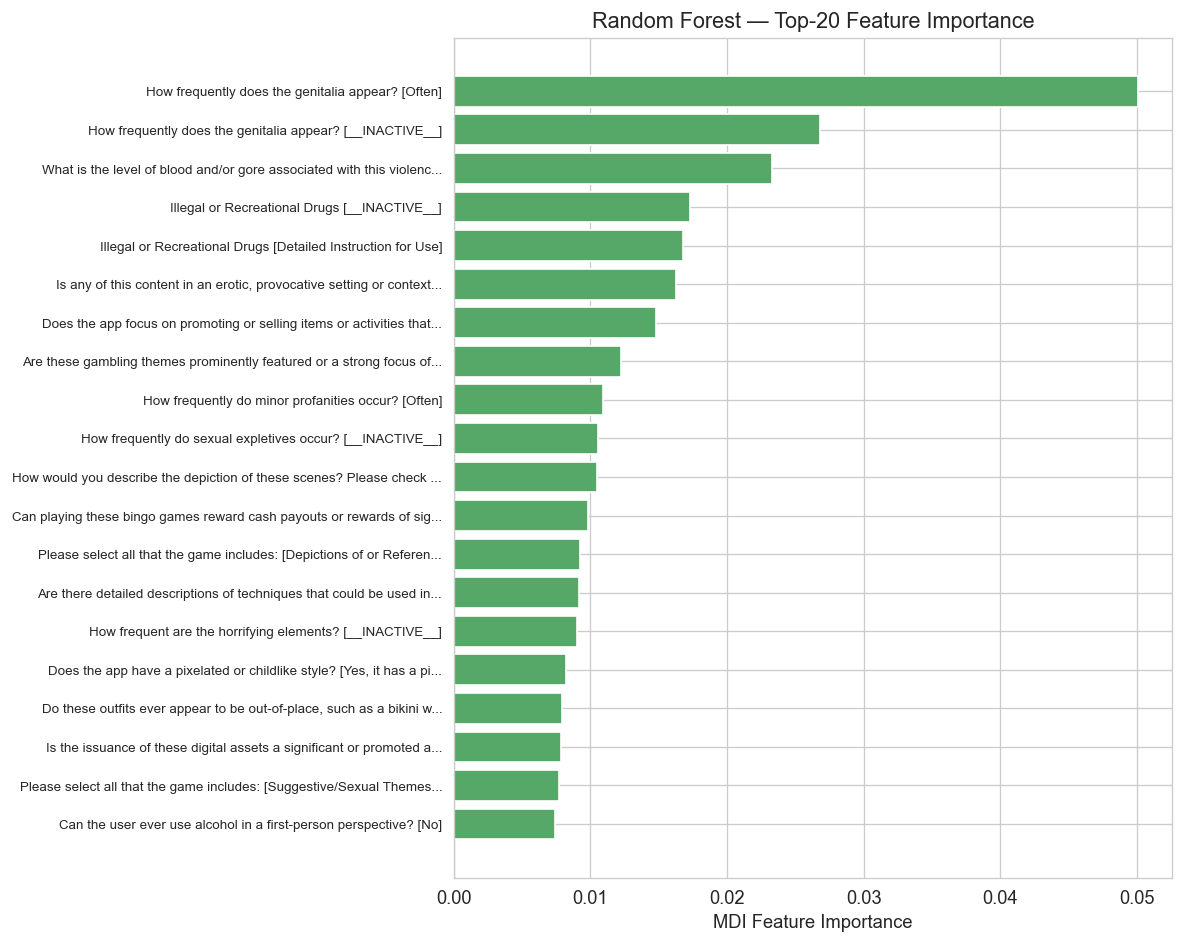


RF 有效特征数（importance > 0）: 689 / 758
Top-20 特征累积重要性: 0.286 / 1.000
  = 占总重要性的 28.6%


In [11]:
rf_importance = rf_model.feature_importances_  # shape (758,)
top_n = 20
top_idx = np.argsort(rf_importance)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 8))
labels = []
for idx in top_idx[::-1]:  # reverse for horizontal bar
    text = id_to_text.get(idx, feature_names_raw[idx])
    if len(text) > 70: text = text[:67] + "..."
    labels.append(text)
ax.barh(range(top_n), rf_importance[top_idx[::-1]], color="#55a868", edgecolor="white")
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("MDI Feature Importance")
ax.set_title("Random Forest — Top-20 Feature Importance")
plt.tight_layout(); plt.show()

print(f"\nRF 有效特征数（importance > 0）: {(rf_importance > 0).sum()} / 758")
print(f"Top-20 特征累积重要性: {rf_importance[top_idx].sum():.3f} / {rf_importance.sum():.3f}")
print(f"  = 占总重要性的 {rf_importance[top_idx].sum() / rf_importance.sum() * 100:.1f}%")

## 6. 预测不确定性与灰色地带分析

使用表现更好的逻辑回归，分析模型在哪些样本上"纠结"——Top-2 概率差距越小，模型越不确定。
这些灰色地带样本揭示了年龄分级的边界模糊性。

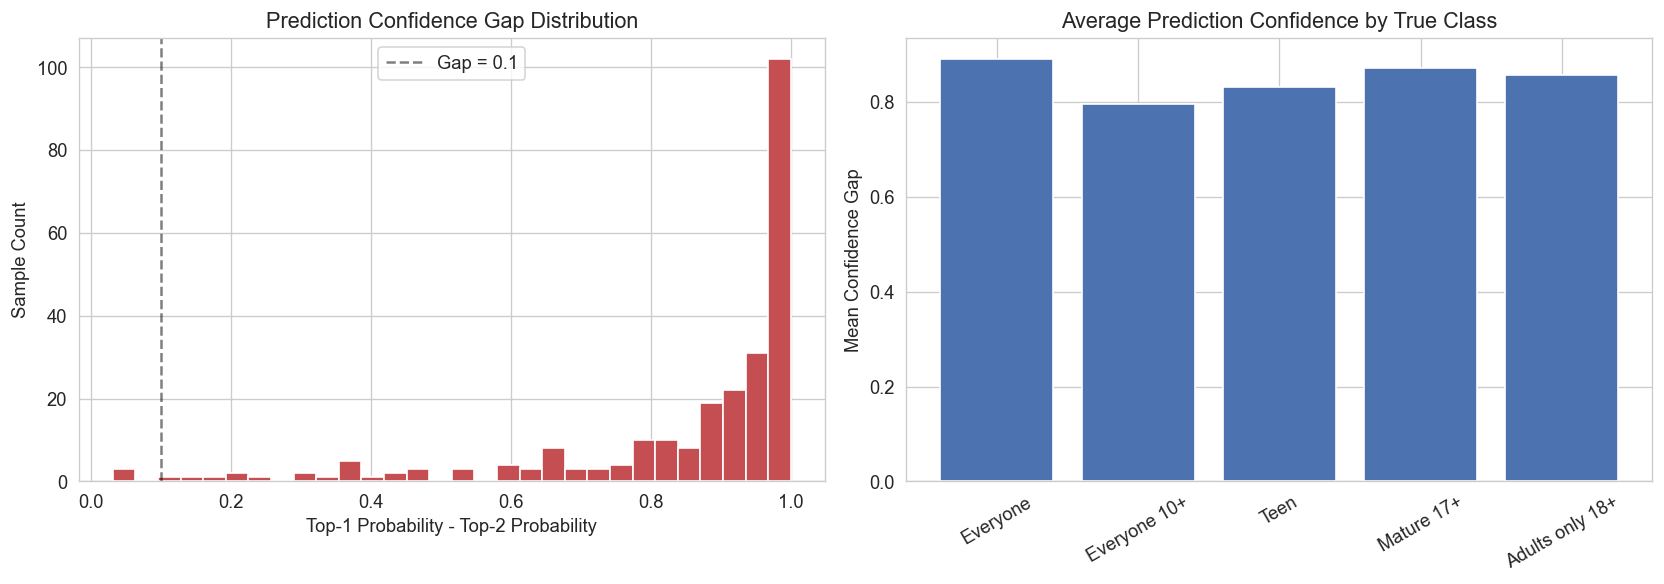

高置信样本 (gap > 0.5): 230 / 253
灰色地带样本 (gap < 0.1): 3 / 253


In [12]:
y_proba = lr_model.predict_proba(X_test)
probs_sorted = np.sort(y_proba, axis=1)
margin_gap = probs_sorted[:, -1] - probs_sorted[:, -2]  # Top1 prob - Top2 prob

# ── 不确定性分布 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(margin_gap, bins=30, color="#c44e52", edgecolor="white")
axes[0].axvline(x=0.1, color="black", linestyle="--", alpha=0.5, label="Gap = 0.1")
axes[0].set_xlabel("Top-1 Probability - Top-2 Probability")
axes[0].set_ylabel("Sample Count")
axes[0].set_title("Prediction Confidence Gap Distribution")
axes[0].legend()

# 各类别平均置信度
true_class_gap = [margin_gap[y_test == i].mean() for i in range(5)]
axes[1].bar(CLASS_NAMES, true_class_gap, color="#4c72b0", edgecolor="white")
axes[1].set_ylabel("Mean Confidence Gap")
axes[1].set_title("Average Prediction Confidence by True Class")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(f"高置信样本 (gap > 0.5): {(margin_gap > 0.5).sum()} / {len(margin_gap)}")
print(f"灰色地带样本 (gap < 0.1): {(margin_gap < 0.1).sum()} / {len(margin_gap)}")

In [13]:
# ── Top-10 最不确定样本 ──
uncertain_indices = np.argsort(margin_gap)[:10]

print("Top-10 最不确定的样本 (灰色地带):")
print(f"{'样本':<6} {'真实标签':<16} {'第一预测':<16} {'P1':<8} {'第二预测':<16} {'P2':<8} {'Gap':<8}")
print("-" * 82)
for idx in uncertain_indices:
    top2 = np.argsort(y_proba[idx])[-2:][::-1]
    print(f"{idx:<6} {CLASS_NAMES[y_test[idx]]:<16} {CLASS_NAMES[top2[0]]:<16}"
          f"{y_proba[idx][top2[0]]:.4f}  {CLASS_NAMES[top2[1]]:<16}"
          f"{y_proba[idx][top2[1]]:.4f}  {margin_gap[idx]:.4f}")

Top-10 最不确定的样本 (灰色地带):
样本     真实标签             第一预测             P1       第二预测             P2       Gap     
----------------------------------------------------------------------------------
45     Teen             Teen            0.5145  Everyone 10+    0.4829  0.0315
59     Adults only 18+  Teen            0.4183  Mature 17+      0.3866  0.0316
99     Adults only 18+  Teen            0.5306  Adults only 18+ 0.4687  0.0619
140    Everyone 10+     Teen            0.5319  Everyone 10+    0.4166  0.1153
64     Mature 17+       Mature 17+      0.5200  Everyone 10+    0.3842  0.1358
47     Adults only 18+  Everyone 10+    0.5715  Adults only 18+ 0.3864  0.1851
141    Teen             Teen            0.5970  Everyone 10+    0.4026  0.1944
81     Adults only 18+  Adults only 18+ 0.5992  Mature 17+      0.4008  0.1985
108    Everyone 10+     Teen            0.6123  Everyone        0.3844  0.2279
10     Everyone 10+     Teen            0.6366  Everyone 10+    0.3443  0.2924


In [14]:
# ── 解剖最不确定样本 —— 哪些特征在拉扯 ──
sample_idx = uncertain_indices[0]
sample_proba = y_proba[sample_idx]
pred_class = int(np.argmax(sample_proba))
true_class = int(y_test[sample_idx])

print(f"样本 #{sample_idx}: 真实 = {CLASS_NAMES[true_class]}, 预测 = {CLASS_NAMES[pred_class]}")
print(f"  各类概率: {dict(zip(CLASS_NAMES, [f'{p:.4f}' for p in sample_proba]))}")
print(f"\n对该样本影响最大的特征 (L1 系数 x 特征值):")

sample_features = X_test[sample_idx]
impacts = []
for feat_idx in np.where(sample_features != 0)[0]:
    impact = coef[pred_class, feat_idx] * sample_features[feat_idx]
    impacts.append((feat_idx, impact))

impacts.sort(key=lambda x: abs(x[1]), reverse=True)
for rank, (feat_idx, impact) in enumerate(impacts[:15], 1):
    direction = "→ 推高" if impact > 0 else "← 压低"
    text = id_to_text.get(feat_idx, feature_names_raw[feat_idx])
    if len(text) > 75: text = text[:72] + "..."
    print(f"  {rank:2d}. [{impact:+.4f}] {direction} {text}")

样本 #45: 真实 = Teen, 预测 = Teen
  各类概率: {'Everyone': '0.0011', 'Everyone 10+': '0.4829', 'Teen': '0.5145', 'Mature 17+': '0.0011', 'Adults only 18+': '0.0004'}

对该样本影响最大的特征 (L1 系数 x 特征值):
   1. [-3.9781] ← 压低 How frequent are the horrifying elements? [__INACTIVE__]
   2. [+3.8001] → 推高 How frequently do the female human breasts with nipples appear? [__INACT...
   3. [-3.2551] ← 压低 How frequently does moderate swearing occur? [__INACTIVE__]
   4. [+3.1091] → 推高 How frequently does the genitalia appear? [__INACTIVE__]
   5. [+2.0859] → 推高 Can the app contain discriminatory language? [Yes]
   6. [+1.9017] → 推高 Is the app primarily a news or educational product? [No]
   7. [+1.7777] → 推高 How frequently do sexual expletives occur? [__INACTIVE__]
   8. [-1.5509] ← 压低 How frequently do the nipple-less breasts appear? [__INACTIVE__]
   9. [+1.4486] → 推高 Is the issuance of these digital assets a significant or promoted aspect...
  10. [-1.2215] ← 压低 How explicitly depicted are these disturbing or 

## 7. 特征冗余度分析

按照逻辑回归的 L1 系数绝对值排序，逐步增加特征数重训模型，
观察需要多少特征才能达到接近全量特征的性能。

In [15]:
from sklearn.linear_model import LogisticRegression

# 按 L1 系数绝对值排序（取各类别的最大绝对值）
max_abs_coef = np.max(np.abs(coef), axis=0)  # shape (758,)
sorted_features = np.argsort(max_abs_coef)[::-1]

# 逐步增加特征训练并评估
feature_counts = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500, 758]
scores = []

X_train_dense = X_train  # already dense
X_test_dense = X_test
y_train = pd.read_csv(TASK4_DIR / "y_train.csv")["label_id"].values

for n in feature_counts:
    selected = sorted_features[:n]
    temp_lr = LogisticRegression(
        C=10.0, l1_ratio=1.0, tol=1e-4, solver="saga", max_iter=3000, random_state=42
    )
    temp_lr.fit(X_train_dense[:, selected], y_train)
    preds = temp_lr.predict(X_test_dense[:, selected])
    scores.append(accuracy_score(y_test, preds))
    print(f"特征数: {n:3d} | Test Accuracy: {scores[-1]:.4f}")

特征数:   5 | Test Accuracy: 0.3874
特征数:  10 | Test Accuracy: 0.4348
特征数:  20 | Test Accuracy: 0.4585
特征数:  30 | Test Accuracy: 0.5138
特征数:  50 | Test Accuracy: 0.6245
特征数:  75 | Test Accuracy: 0.7312
特征数: 100 | Test Accuracy: 0.8142
特征数: 150 | Test Accuracy: 0.9012
特征数: 200 | Test Accuracy: 0.9328
特征数: 300 | Test Accuracy: 0.9289
特征数: 400 | Test Accuracy: 0.9289
特征数: 500 | Test Accuracy: 0.9249
特征数: 758 | Test Accuracy: 0.9209


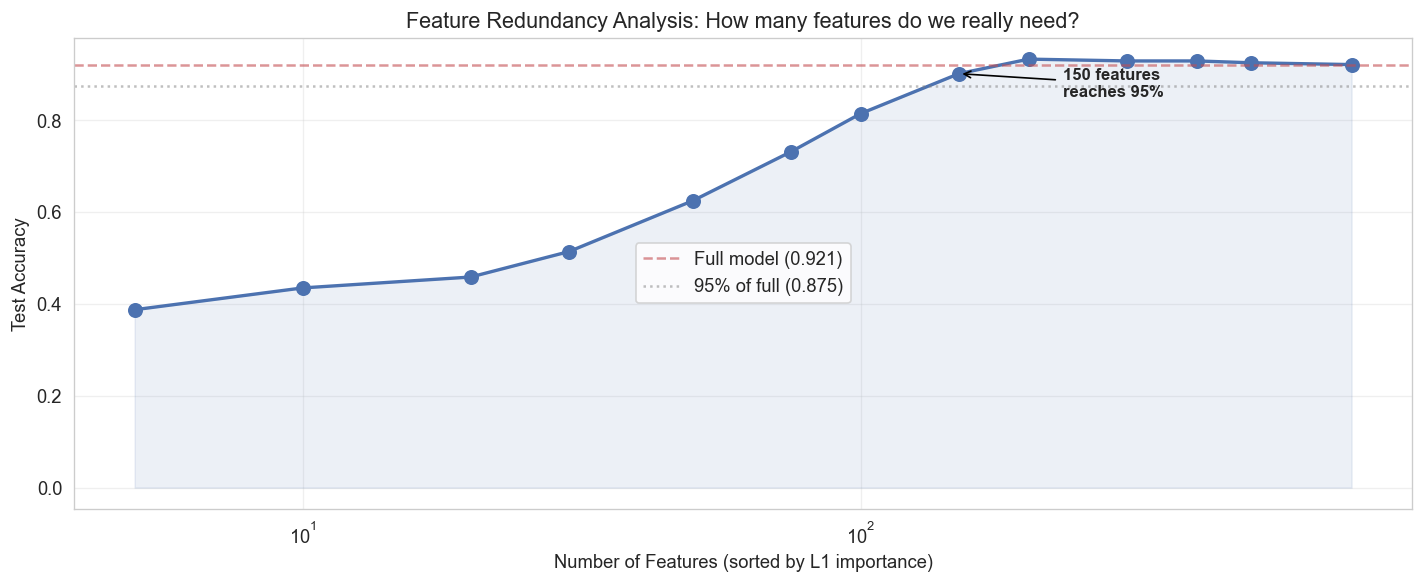

In [16]:
full_accuracy = metrics["logistic_regression"]["splits"]["test"]["accuracy"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(feature_counts, scores, marker="o", color="#4c72b0", linewidth=2, markersize=8)
ax.fill_between(feature_counts, scores, alpha=0.1, color="#4c72b0")
ax.axhline(y=full_accuracy, color="#c44e52", linestyle="--", alpha=0.6,
           label=f"Full model ({full_accuracy:.3f})")
ax.axhline(y=full_accuracy * 0.95, color="gray", linestyle=":", alpha=0.5,
           label=f"95% of full ({full_accuracy * 0.95:.3f})")

# Find the point where we reach 95% of full performance
for n, s in zip(feature_counts, scores):
    if s >= full_accuracy * 0.95:
        ax.annotate(f"{n} features\nreaches 95%", xy=(n, s),
                    xytext=(n + 80, s - 0.05),
                    arrowprops=dict(arrowstyle="->", color="black"),
                    fontsize=10, fontweight="bold")
        break

ax.set_xlabel("Number of Features (sorted by L1 importance)")
ax.set_ylabel("Test Accuracy")
ax.set_title("Feature Redundancy Analysis: How many features do we really need?")
ax.legend()
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. 总结

### 模型排名（Test Set）

| 模型 | Accuracy | Macro F1 | Macro AUC |
|------|:--------:|:--------:|:--------:|
| Logistic Regression | **0.921** | **0.918** | **0.977** |
| Random Forest | 0.783 | 0.797 | 0.945 |

### 关键发现

1. **L1 稀疏解极其有效**：逻辑回归将 758 维特征中大量权重压缩为 0，仅保留少数关键特征，同时达到 0.921 准确率。这证明高维 TF-IDF 中真正有区分力的维度很少。

2. **特征冗余严重**：仅需少量 Top-K 特征即可逼近全量性能——问卷中存在大量对年龄分级没有贡献的问题。

3. **灰色地带反映分级本质**：模型最纠结的样本集中在 "Teen vs Mature 17+" 边界，这与现实中这两个分级的模糊性一致。

4. **随机森林虽然整体性能较低，但特征重要性分析揭示了不同的问题视角**，可作为交叉验证参考。

### 复现方式

```bash
python task5_2_logistic_regression&random_forest/train_models.py
```